# Setup

In [1]:
import numpy as np
from intersect import intersection

from astropy import constants as consts, units as u                                                                                                                                                   
from astropy.modeling.models import BlackBody

import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
plt.rcParams['font.family']      = 'serif'
plt.rcParams['font.serif']       = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# Figure 3: Mass vs. Period Joint Discovery Space

In [3]:
#############################################
# Planet period curve for LISA as a function of planet mass, etc.  : 
#############################################
def period_curve_lisa(snr, distance, mass_planet, mass_star) : 
    prefactor = 0.07
    
    return( prefactor * (snr/5.)**(3./2.) * (distance.to(u.pc)/(150.*u.pc))**(3./2.) * (mass_planet)**(-3./2.) * ( mass_planet*((u.M_jup).to(u.M_sun)) + (mass_star.to(u.M_sun)).value ))
    

In [4]:
#############################################
# Planet mass curve for HWO as a function of planet distance, period, etc. : 
#
#   period is in years; 
#
#   Ref: Amiaux++2025, https://arxiv.org/abs/2511.07113
#############################################
def mass_curve_hwo(SNR, period, distance, mass_star, Ta, Tb, Ra, Rb, verbose=False) : 

    Nobs_per_orbit_min = 6. 
    Nobs1 = np.ones_like(period)*100.    # number of 1-hour pointings; 
    Nobs3 = ((period*u.yr).to(u.hr)).value
    Nobs_hwo = np.maximum(np.minimum(Nobs1, Nobs3),Nobs_per_orbit_min)

    # HWO Paper target star numbers, i.e. numbers assumed in the given SNR expression:
    d_hwo = 10.*u.pc      
    Rstar_hwo = 0.997 * u.R_sun
    Tstar_hwo = 5660 * u.K  

    ref_wavelengths = np.arange(5.5e-7,5.6e-7)*u.m
    bb_a = BlackBody(temperature=Ta)
    bb_b = BlackBody(temperature=Tb)
    bb_hwo = BlackBody(temperature=Tstar_hwo)
    flux_ratio = ((Ra**2*bb_a(ref_wavelengths)[0]+Rb**2*bb_b(ref_wavelengths)[0])/distance**2) / (bb_hwo(ref_wavelengths)[0]*Rstar_hwo**2/d_hwo**2 ) 
    if( verbose ) : 
        print(f"flux_ratio = {flux_ratio}")
        print(f"HWO BB = {bb_hwo(ref_wavelengths)}")
        print(f"BB ratio = {bb_hwo(ref_wavelengths) / bb_a(ref_wavelengths)}")

    # Error budget in angular resolution (in micro-arcsecs) : 
    sigma_meas_0 = 0.5   # total baseline uncertainty 
    sigma_astrometric_target = 0.03 * (flux_ratio)**(-0.5)
    sigma_astrometric_calibration = 0.23
    sigma_focplane_calibration = 0.31
    sigma_telescope_calibration = 0.31
    sigma_astron_source = 0.06
    sigma_meas = np.sqrt(sigma_astrometric_target**2 + sigma_astrometric_calibration**2 + sigma_focplane_calibration**2 + sigma_telescope_calibration**2 + sigma_astron_source**2)

    if( verbose ) : 
        print("sigma_meas = ", sigma_meas) 
        print("sigma_astrometric_target = ",  sigma_astrometric_target)
    
    Mearth = consts.M_earth / consts.M_jup     # in terms of jupiter masses
    mp_hwo = Mearth * (period**(-2./3.)) * ((mass_star.to(u.M_sun)).value)**(2./3.) * ((distance.to(u.pc)/(d_hwo.to(u.pc))).value)  * (SNR / 6.) * (Nobs_hwo/100.)**(-1./2.) * (sigma_meas/sigma_meas_0) 

    return(mp_hwo)

In [5]:
#############################################
# Comparison choices 
#############################################
mission_lifetime = 10.    # years  
SNR  = 5.                 # SNR used to set requirements 

# Bounds of the plot:     
x_min, x_max = 3e-3, 100
y_min, y_max = 2e-2, 13

##########################################
# Parameters for the ZTFJ2243-like source and mock observations : 
#########################################
Ma = 0.323 * u.M_sun
Mb = 0.335 * u.M_sun
Ra = 0.0298 * u.R_sun
Rb = 0.0275 * u.R_sun
Ta = 26300 * u.K
Tb = 19200 * u.K
period_dwd = ((527.93*u.s).to(u.yr)).value
Mstar = Ma+Mb   
distance = 150. * u.pc

In [6]:
##########################################
# LISA Mp vs. Tp Data for the source: 
#########################################

# Best fit for the LISA data in closed-form (we will use this): 
Mp = np.logspace(-3,2,num=200)
Tp = period_curve_lisa(SNR, distance, Mp, Mstar)
Mp[Tp>mission_lifetime] = 1e3
x = Tp
x_curve = x
y_curve_lisa = Mp

In [7]:
#################################################
# HWO observation parameters and SNR calculation: 
#################################################

mp_hwo = mass_curve_hwo(SNR, x, distance, Mstar, Ta, Tb, Ra, Rb)
mp_hwo[x > mission_lifetime] = 200.

y_curve_hwo = mp_hwo

In [8]:
##########################################
# JWST region : 
#########################################
y_curve_jwst = np.full_like(x_curve, 7.0, dtype=float)

##########################################
# Gaia region : 
#########################################
y_curve_gaia = (10./0.3)*y_curve_hwo

In [9]:
# Colors  
c_lisa = "#3B82F6"   # blue
c_jwst = "#8A8A8A"   # grey
c_hwo  = "#008800"   # green
c_gaia = "#880000"   # red 

alpha = 0.20

## Plot: log-log version

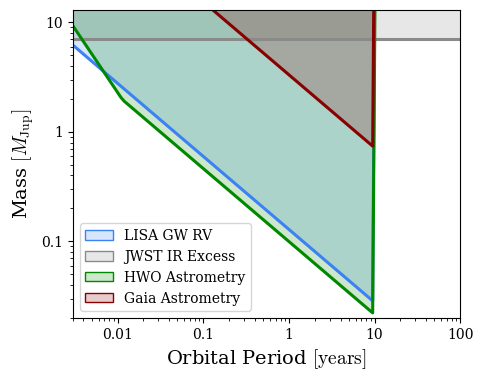

In [10]:
fig, ax = plt.subplots(figsize=(5,4))

# Sensitivity Regions
ax.loglog(x_curve, y_curve_lisa, color=c_lisa, lw=2.2)
ax.loglog(x_curve, y_curve_jwst, color=c_jwst, lw=2.2)
ax.loglog(x_curve, y_curve_hwo,  color=c_hwo,  lw=2.2)
ax.loglog(x_curve, y_curve_gaia, color=c_gaia, lw=2.2)

# --> Sort for fill_between safety
order = np.argsort(x_curve)
xs    = x_curve[order]
ax.fill_between(xs, np.minimum(y_curve_lisa[order], y_max), y_max, color=c_lisa, alpha=alpha, linewidth=0)
ax.fill_between(xs, np.minimum(y_curve_jwst[order], y_max), y_max, color=c_jwst, alpha=alpha, linewidth=0)
ax.fill_between(xs, np.minimum(y_curve_hwo[order],  y_max), y_max, color=c_hwo,  alpha=alpha, linewidth=0)
ax.fill_between(xs, np.minimum(y_curve_gaia[order], y_max), y_max, color=c_gaia, alpha=alpha, linewidth=0)

# Axes
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xticks([1e-2,1e-1,1,1e1,1e2]), ax.set_xticklabels(['0.01', '0.1', '1', '10', '100'])
ax.set_xlabel(r'Orbital Period $[\text{years}]$', fontsize=14)

ax.set_yticks([1e-1,1,1e1]), ax.set_yticklabels(['0.1', '1', '10'])
ax.set_ylabel(r'Mass $[M_\text{Jup}]$', fontsize=14)

# Remove grid explicitly
ax.grid(False)

legend_elements = [
    Patch(facecolor=(c_lisa,alpha), edgecolor=c_lisa, label="LISA GW RV"),
    Patch(facecolor=(c_jwst,alpha), edgecolor=c_jwst, label="JWST IR Excess"),
    Patch(facecolor=(c_hwo,alpha),  edgecolor=c_hwo,  label="HWO Astrometry"),
    Patch(facecolor=(c_gaia,alpha), edgecolor=c_gaia, label="Gaia Astrometry"),
]
ax.legend(handles=legend_elements, frameon=True, loc="lower left")

# plt.savefig('./CombinedDetectLimits-loglog.pdf', bbox_inches='tight')
plt.show()

## Plot: log-linear version

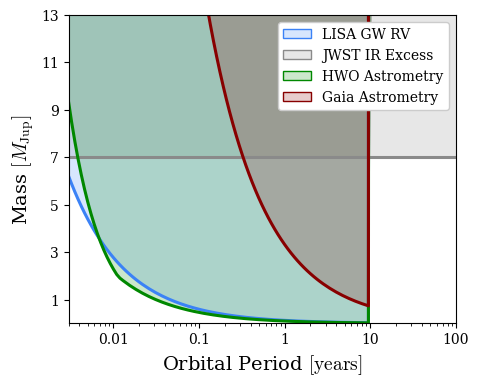

In [11]:
fig, ax = plt.subplots(figsize=(5,4))

# Sensitivity Regions
ax.semilogx(x_curve, y_curve_lisa, color=c_lisa, lw=2.2)
ax.semilogx(x_curve, y_curve_jwst, color=c_jwst, lw=2.2)
ax.semilogx(x_curve, y_curve_hwo,  color=c_hwo,  lw=2.2)
ax.semilogx(x_curve, y_curve_gaia, color=c_gaia, lw=2.2)

# --> Sort for fill_between safety
order = np.argsort(x_curve)
xs    = x_curve[order]
ax.fill_between(xs, np.minimum(y_curve_lisa[order], y_max), y_max, color=c_lisa, alpha=alpha, linewidth=0)
ax.fill_between(xs, np.minimum(y_curve_jwst[order], y_max), y_max, color=c_jwst, alpha=alpha, linewidth=0)
ax.fill_between(xs, np.minimum(y_curve_hwo[order],  y_max), y_max, color=c_hwo,  alpha=alpha, linewidth=0)
ax.fill_between(xs, np.minimum(y_curve_gaia[order], y_max), y_max, color=c_gaia, alpha=alpha, linewidth=0)

# Axes
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xticks([1e-2,1e-1,1,1e1,1e2]), ax.set_xticklabels(['0.01', '0.1', '1', '10', '100'])
ax.set_xlabel(r'Orbital Period $[\text{years}]$', fontsize=14)

ax.set_yticks(np.arange(1,y_max+1,2))
ax.set_ylabel(r'Mass $[M_\text{Jup}]$', fontsize=14)

# Remove grid explicitly
ax.grid(False)

legend_elements = [
    Patch(facecolor=(c_lisa,alpha), edgecolor=c_lisa, label="LISA GW RV"),
    Patch(facecolor=(c_jwst,alpha), edgecolor=c_jwst, label="JWST IR Excess"),
    Patch(facecolor=(c_hwo,alpha),  edgecolor=c_hwo,  label="HWO Astrometry"),
    Patch(facecolor=(c_gaia,alpha), edgecolor=c_gaia, label="Gaia Astrometry"),
]
ax.legend(handles=legend_elements, frameon=True, framealpha=1, loc="upper right")

# plt.savefig('./CombinedDetectLimits-loglinear.pdf', bbox_inches='tight')
plt.show()

## Plot: version used in paper

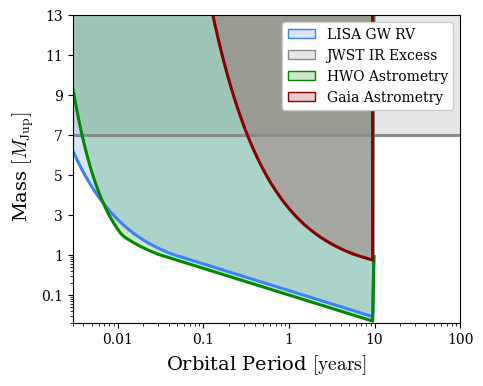

In [12]:
fig, ax = plt.subplots(figsize=(5,4))

# Sensitivity Regions
ax.loglog(x_curve, y_curve_lisa, color=c_lisa, lw=2.2)
ax.loglog(x_curve, y_curve_jwst, color=c_jwst, lw=2.2)
ax.loglog(x_curve, y_curve_hwo,  color=c_hwo,  lw=2.2)
ax.loglog(x_curve, y_curve_gaia, color=c_gaia, lw=2.2)
ax.set_ylim((y_min, 1))

divider = make_axes_locatable(ax)
axtop = divider.append_axes("top", size=2.4, pad=0)

axtop.semilogx(x_curve, y_curve_lisa, color=c_lisa, lw=2.2)
axtop.semilogx(x_curve, y_curve_jwst, color=c_jwst, lw=2.2)
axtop.semilogx(x_curve, y_curve_hwo,  color=c_hwo,  lw=2.2)
axtop.semilogx(x_curve, y_curve_gaia, color=c_gaia, lw=2.2)
axtop.set_ylim((1, y_max))


ax.spines['top'].set_visible(False), axtop.spines['bottom'].set_visible(False)  # turn off axis spine
plt.setp(axtop.get_xticklabels(), visible=False)  # turn off tick labels
axtop.tick_params(axis='x',length=0), axtop.xaxis.minorticks_off()  # turn off major/minor ticks


# --> Sort for fill_between safety
order = np.argsort(x_curve)
xs    = x_curve[order]
ax.fill_between(xs, np.minimum(y_curve_lisa[order], y_max), y_max, color=c_lisa, alpha=alpha, linewidth=0)
ax.fill_between(xs, np.minimum(y_curve_jwst[order], y_max), y_max, color=c_jwst, alpha=alpha, linewidth=0)
ax.fill_between(xs, np.minimum(y_curve_hwo[order],  y_max), y_max, color=c_hwo,  alpha=alpha, linewidth=0)
ax.fill_between(xs, np.minimum(y_curve_gaia[order], y_max), y_max, color=c_gaia, alpha=alpha, linewidth=0)
axtop.fill_between(xs, np.minimum(y_curve_lisa[order], y_max), y_max, color=c_lisa, alpha=alpha, linewidth=0)
axtop.fill_between(xs, np.minimum(y_curve_jwst[order], y_max), y_max, color=c_jwst, alpha=alpha, linewidth=0)
axtop.fill_between(xs, np.minimum(y_curve_hwo[order],  y_max), y_max, color=c_hwo,  alpha=alpha, linewidth=0)
axtop.fill_between(xs, np.minimum(y_curve_gaia[order], y_max), y_max, color=c_gaia, alpha=alpha, linewidth=0)

# Axes
ax.set_xlim(x_min, x_max), axtop.set_xlim(x_min, x_max)

ax.set_xticks([1e-2,1e-1,1,1e1,1e2]), ax.set_xticklabels(['0.01', '0.1', '1', '10', '100'])
ax.set_xlabel(r'Orbital Period $[\text{years}]$', fontsize=14)

ax.set_yticks([1e-1,1]), ax.set_yticklabels(['0.1', '1'])
axtop.set_yticks(np.arange(3,y_max+1,2))
ax.set_ylabel(r'Mass $[M_\text{Jup}]$', fontsize=14, y=2.3)

# Remove grid explicitly
ax.grid(False)

legend_elements = [
    Patch(facecolor=(c_lisa,alpha), edgecolor=c_lisa, label="LISA GW RV"),
    Patch(facecolor=(c_jwst,alpha), edgecolor=c_jwst, label="JWST IR Excess"),
    Patch(facecolor=(c_hwo,alpha),  edgecolor=c_hwo,  label="HWO Astrometry"),
    Patch(facecolor=(c_gaia,alpha), edgecolor=c_gaia, label="Gaia Astrometry"),
]
axtop.legend(handles=legend_elements, frameon=True, framealpha=1, loc="upper right")

# plt.savefig('./CombinedDetectLimits.pdf', bbox_inches='tight')
plt.show()

# Figure 4: Mass vs. Distance Joint Discovery Space

In [13]:
x_min, x_max = [1.,1e5]
y_min, y_max = [1e-4,1e2]
x_d = np.logspace(np.log10(x_min),np.log10(x_max),num=200) # in parsec  
distance = x_d * u.pc
Tp_d = 1. # in years 
mp_hwo_d = mass_curve_hwo(SNR, Tp_d, distance, Mstar, Ta, Tb, Ra, Rb) 
mp_gaia_d = (10./0.3)*mp_hwo_d 


# Solve the linear LISA period(mass,distance) for the non-linear relationship mass(period,distance)
Mpvals = np.logspace(np.log10(y_min),np.log10(y_max),2_000)
sols = []
for d in distance:
    y = period_curve_lisa(SNR, d, Mpvals, Mstar).value
    f = Tp_d * np.ones_like(y)
    xintersect, _, _, _ = intersection(Mpvals, y, Mpvals, f)
    sols = np.append(sols, xintersect)  
mp_lisa_d = sols

c_gc = "k" 
d_galcen = 8230. # in parsecs

x_hwo,  y_hwo,  i_hwo, j_hwo = intersection(x_d, mp_hwo_d, x_d, mp_lisa_d)
x_gaia, y_gaia, i_hwo, j_hwo = intersection(x_d, mp_gaia_d, x_d, mp_lisa_d)
x_gc,   y_gc,   i_gc,  j_gc  = intersection([d_galcen,d_galcen], [y_min,y_max], x_d, mp_lisa_d)

print(f"x_hwo = {x_hwo} , y_hwo = {y_hwo} ")
print(f"x_gaia = {x_gaia} , y_gaia = {y_gaia} ")
print(f"x_gc = {x_gc} , y_gc = {y_gc} ")

x_hwo = [196.91579826] , y_hwo = [0.16871267] 
x_gaia = [] , y_gaia = [] 
x_gc = [8230.] , y_gc = [7.09846626] 


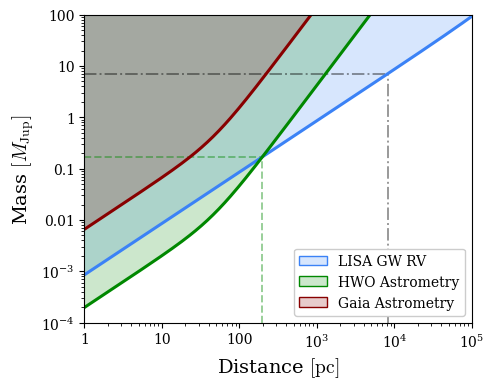

In [14]:
fig, ax = plt.subplots(figsize=(5,4))

ls='--'
ls2='-.'
alpha_line = 0.40

# LISA sensitivity surpases HWO reference
ax.plot((x_hwo,x_hwo), (y_min,*y_hwo),   color=c_hwo, lw=1.4, alpha=alpha_line, ls=ls)
ax.plot((x_min,*x_hwo), (*y_hwo,*y_hwo), color=c_hwo, lw=1.4, alpha=alpha_line, ls=ls)

# Galactic Center reference
ax.plot((x_gc,x_gc), (y_min,*y_gc),   color=c_gc, lw=1.4, alpha=alpha_line, ls=ls2)
ax.plot((x_min,*x_gc), (*y_gc,*y_gc), color=c_gc, lw=1.4, alpha=alpha_line, ls=ls2)

# Sensitivity Regions
ax.loglog(x_d, mp_lisa_d, color=c_lisa, lw=2.2)
ax.loglog(x_d, mp_hwo_d,  color=c_hwo,  lw=2.2)
ax.loglog(x_d, mp_gaia_d, color=c_gaia, lw=2.2)

ax.fill_between(x_d, np.minimum(mp_lisa_d, y_max), y_max, color=c_lisa, alpha=alpha, linewidth=0)
ax.fill_between(x_d, np.minimum(mp_hwo_d, y_max),  y_max, color=c_hwo,  alpha=alpha, linewidth=0)
ax.fill_between(x_d, np.minimum(mp_gaia_d, y_max), y_max, color=c_gaia, alpha=alpha, linewidth=0)

# Axes
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xticks([1e0,1e1,1e2,1e3,1e4,1e5]), ax.set_xticklabels(['1', '10', '100', '$\\mathdefault{10^{3}}$', '$\\mathdefault{10^{4}}$', '$\\mathdefault{10^{5}}$'])
ax.set_xlabel(r'Distance $[\text{pc}]$', fontsize=14)

ax.set_yticks([1e-4,1e-3,1e-2,1e-1,1e0,1e1,1e2]), ax.set_yticklabels(['$\\mathdefault{10^{-4}}$', '$\\mathdefault{10^{-3}}$', '0.01', '0.1', '1', '10', '100'])
ax.set_ylabel(r'Mass $[M_\text{Jup}]$',  fontsize=14)

ax.grid(False)

legend_elements = [
    Patch(facecolor=(c_lisa,alpha), edgecolor=c_lisa, label="LISA GW RV"),
    Patch(facecolor=(c_hwo,alpha),  edgecolor=c_hwo,  label="HWO Astrometry"),
    Patch(facecolor=(c_gaia,alpha), edgecolor=c_gaia, label="Gaia Astrometry"),
]
ax.legend(handles=legend_elements, frameon=True, framealpha=1, loc="lower right")

# plt.savefig('distance-reach.pdf', bbox_inches='tight')
plt.show()